libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# PART A

random vectors

In [2]:
rng = np.random.default_rng()

# Data points
X1 = rng.random(5)
X1 = 5*X1
X1.sort()
Y1 = rng.random(5)
Y1 = 5*Y1

using least squares

In [3]:
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X1, np.ones(len(X1))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y1, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

Slope: 0.5330453141637883, Intercept: 1.1573781488837294


plotting

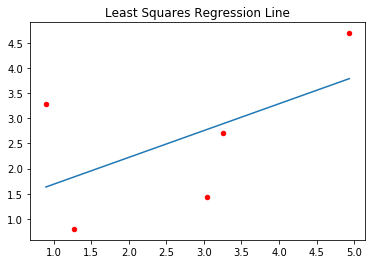

In [4]:
plt.scatter(X1,Y1,20,"r")
plt.plot(X1,m*X1+c)
plt.title("Least Squares Regression Line")
plt.show()

evaluation MSE and R-squared for least squares

In [5]:
# Mean Squared Error (MSE)
mselsq = np.mean((Y1 - (m*X1+c))**2)
print(f'Mean Squared Error: {mselsq:.4f}')
# R-squared value
ss_total = np.sum((Y1 - np.mean(Y1))**2)
ss_res = np.sum((Y1 - (m*X1+c))**2)
r_squaredlsq = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredlsq:.4f}')

Mean Squared Error: 1.2876
R-squared: 0.3213


using polynomial fit

In [6]:
# Polynomial fitting using NumPy's polyfit
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(X1, Y1, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,5,50)
y_pred = polynomial(x)

Polynomial Coefficients:  [ -0.81234524   7.79400925 -21.07919092  16.55497445]


plotting

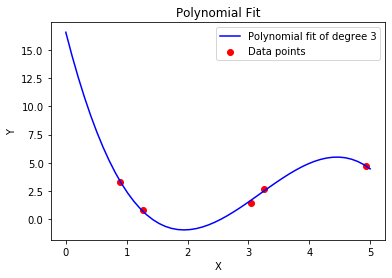

In [7]:
# Step 4: Plotting the results
plt.scatter(X1, Y1, color='red', label='Data points') # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (cubic) fit

In [8]:
# Mean Squared Error (MSE)
msecub = np.mean((Y1 - polynomial(X1))**2)
print(f'Mean Squared Error: {msecub:.4f}')
# R-squared value
ss_total = np.sum((Y1 - np.mean(Y1))**2)
ss_res = np.sum((Y1 - polynomial(X1))**2)
r_squaredcub = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredcub:.4f}')

Mean Squared Error: 0.0225
R-squared: 0.9881


which one is better

In [9]:
if msecub < mselsq and r_squaredcub > r_squaredlsq:
    print("Polynomial fit is the better model.")
elif mselsq < msecub and r_squaredlsq > r_squaredcub:
    print("Linear least squares is the better model.")
else:
    print("Both models perform similarly.")

Polynomial fit is the better model.


# PART B

using new data set (random line with perterbation) so that the effect can be seen better

In [10]:
truem = 3 * rng.random() + 2
truec = 3 * rng.random() + 2

print(f"true m: {truem}")
print(f"true c: {truec}")

X = np.arange(0,1,.04)
rand = rng.random(25)
rand = 2*(rand-0.5)
Y = truem*X+truec+2*rand

true m: 3.5795547543595094
true c: 4.9893103861737895


using least squares

In [11]:
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

Slope: 4.945582892386343, Intercept: 4.481251775707249


plotting

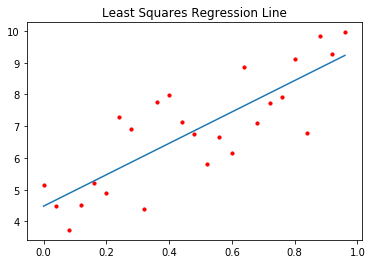

In [12]:
plt.scatter(X,Y,10,"r")
plt.plot(X,m*X+c)
plt.title("Least Squares Regression Line")
plt.show()

evaluation MSE and R-squared for least squares

In [13]:
# Mean Squared Error (MSE)
mselsq = np.mean((Y - (m*X+c))**2)
print(f'Mean Squared Error: {mselsq:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - (m*X+c))**2)
r_squaredlsq = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredlsq:.4f}')

Mean Squared Error: 1.0020
R-squared: 0.6701


using polynomial fit of degree 3

In [14]:
# Polynomial fitting using NumPy's polyfit
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [ 13.36161204 -18.72406157  11.68837646   4.03806116]


plotting

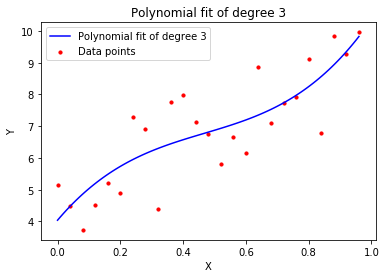

In [15]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (cubic) fit

In [16]:
# Mean Squared Error (MSE)
msecub = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msecub:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredcub = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredcub:.4f}')

Mean Squared Error: 0.9382
R-squared: 0.6911


using polynomial fit of degree 4

In [17]:
# Polynomial fitting using NumPy's polyfit
degree = 4 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [ 41.11364413 -65.57658469  29.3624566    1.90004006   4.42151134]


plotting

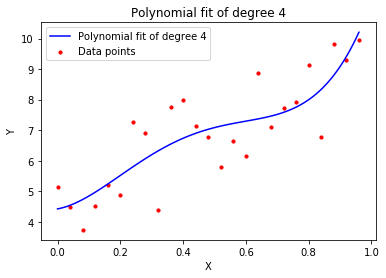

In [18]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 4) fit

In [19]:
# Mean Squared Error (MSE)
msefour = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msefour:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredfour = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredfour:.4f}')

Mean Squared Error: 0.9016
R-squared: 0.7031


using polynomial fit of degree 5

In [20]:
# Polynomial fitting using NumPy's polyfit
degree = 5 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-243.58310114  625.71308686 -559.88789126  202.40389165  -20.04390033
    4.92635583]


plotting

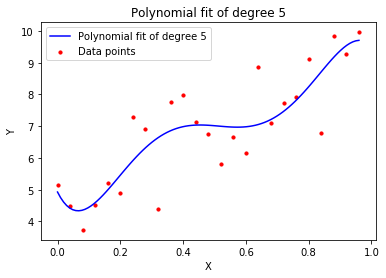

In [21]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 5) fit

In [22]:
# Mean Squared Error (MSE)
msefive = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msefive:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredfive = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredfive:.4f}')

Mean Squared Error: 0.8240
R-squared: 0.7287


using polynomial fit of degree 6

In [23]:
# Polynomial fitting using NumPy's polyfit
degree = 6 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [  777.48458267 -2482.73869922  3052.03042811 -1779.07418782
   482.45015163   -44.05711522     5.26035425]


plotting

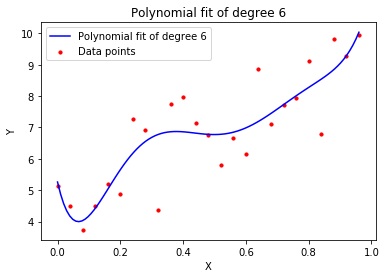

In [24]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 6) fit

In [25]:
# Mean Squared Error (MSE)
msesix = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msesix:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredsix = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredsix:.4f}')

Mean Squared Error: 0.7770
R-squared: 0.7441


using polynomial fit of degree 7

In [26]:
# Polynomial fitting using NumPy's polyfit
degree = 7 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [  489.7282078   -868.00219555  -306.47695511  1620.20377925
 -1293.00546371   403.2883612    -39.20319104     5.21957259]


plotting

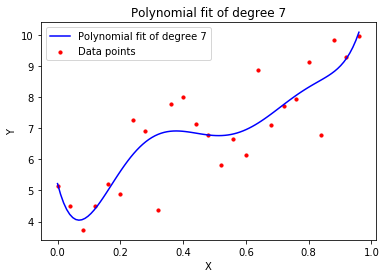

In [27]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 7) fit

In [28]:
# Mean Squared Error (MSE)
mseseven = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {mseseven:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredseven = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredseven:.4f}')

Mean Squared Error: 0.7759
R-squared: 0.7445


using polynomial fit of degree 8

In [29]:
# Polynomial fitting using NumPy's polyfit
degree = 8 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-5.37294092e+03  2.11218213e+04 -3.30987703e+04  2.59672557e+04
 -1.02821280e+04  1.64744845e+03  4.51974137e+01 -2.28015712e+01
  5.13843922e+00]


plotting

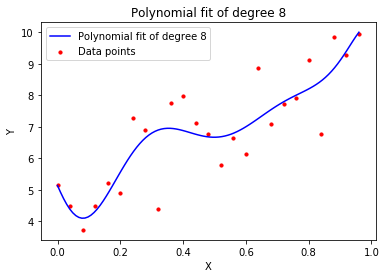

In [30]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 8) fit

In [31]:
# Mean Squared Error (MSE)
mseeight = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {mseeight:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredeight = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredeight:.4f}')

Mean Squared Error: 0.7686
R-squared: 0.7469


using polynomial fit of degree 9

In [32]:
# Polynomial fitting using NumPy's polyfit
degree = 9 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-3.91396556e+04  1.63710371e+05 -2.83603881e+05  2.63586081e+05
 -1.42809392e+05  4.63106968e+04 -9.05481907e+03  1.06045793e+03
 -5.88942339e+01  5.23856549e+00]


plotting

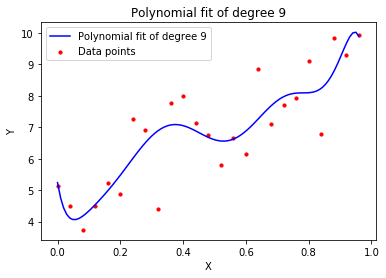

In [33]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 9) fit

In [34]:
# Mean Squared Error (MSE)
msenine = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msenine:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squarednine = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squarednine:.4f}')

Mean Squared Error: 0.7475
R-squared: 0.7539


using polynomial fit of degree 10

In [35]:
# Polynomial fitting using NumPy's polyfit
degree = 10 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-9.77520647e+04  4.30070255e+05 -7.94712610e+05  8.02197243e+05
 -4.81607330e+05  1.74779187e+05 -3.64459865e+04  3.39155528e+03
  1.08719201e+02 -3.16592237e+01  5.19908117e+00]


plotting

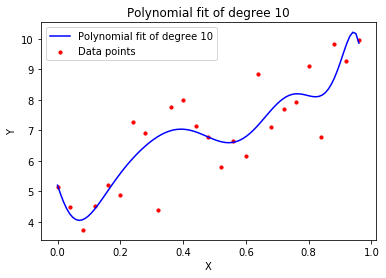

In [36]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 10) fit

In [37]:
# Mean Squared Error (MSE)
mseten = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {mseten:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredten = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredten:.4f}')

Mean Squared Error: 0.7405
R-squared: 0.7562


using polynomial fit of degree 11

In [38]:
# Polynomial fitting using NumPy's polyfit
degree = 11 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [ 1.19903694e+06 -6.42866713e+06  1.48856597e+07 -1.94835739e+07
  1.58443928e+07 -8.28631635e+06  2.78762825e+06 -5.85115487e+05
  7.10906628e+04 -4.19196337e+03  7.09831139e+01  5.12804776e+00]


plotting

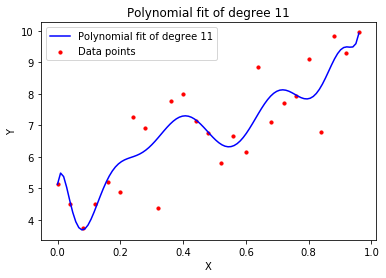

In [39]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 11) fit

In [40]:
# Mean Squared Error (MSE)
mseeleven = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {mseeleven:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredeleven = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredeleven:.4f}')

Mean Squared Error: 0.6877
R-squared: 0.7736


using polynomial fit of degree 12

In [41]:
# Polynomial fitting using NumPy's polyfit
degree = 12 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [ 9.18715246e+05 -4.09276287e+06  6.92935668e+06 -4.52772979e+06
 -1.53959208e+06  4.84748927e+06 -3.76761146e+06  1.55702173e+06
 -3.70734717e+05  4.88047808e+04 -2.98336070e+03  4.61061621e+01
  5.13543084e+00]


plotting

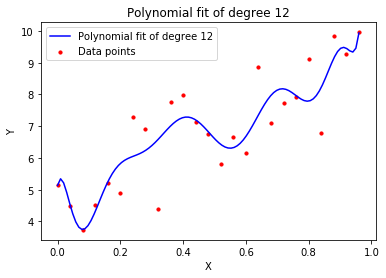

In [42]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 12) fit

In [43]:
# Mean Squared Error (MSE)
msetwelve = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msetwelve:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredtwelve = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredtwelve:.4f}')

Mean Squared Error: 0.6862
R-squared: 0.7740


using polynomial fit of degree 13

In [44]:
# Polynomial fitting using NumPy's polyfit
degree = 13 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [-1.29651488e+07  8.18212438e+07 -2.27826009e+08  3.68083422e+08
 -3.81730459e+08  2.65464991e+08 -1.25576302e+08  4.01418972e+07
 -8.44304649e+06  1.11009876e+06 -8.39415381e+04  3.31395345e+03
 -6.90341287e+01  5.14843402e+00]


plotting

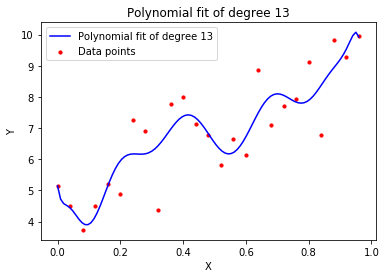

In [45]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 13) fit

In [46]:
# Mean Squared Error (MSE)
msenine = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msenine:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squarednine = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squarednine:.4f}')

Mean Squared Error: 0.6726
R-squared: 0.7785


using polynomial fit of degree 14

In [47]:
# Polynomial fitting using NumPy's polyfit
degree = 14 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [ 9.04689069e+07 -6.20916205e+08  1.90984001e+09 -3.47347407e+09
  4.14971576e+09 -3.42093802e+09  1.98914545e+09 -8.19354461e+08
  2.36669316e+08 -4.67359315e+07  6.03216426e+06 -4.72279397e+05
  1.97742908e+04 -3.42899738e+02  5.15878404e+00]


plotting

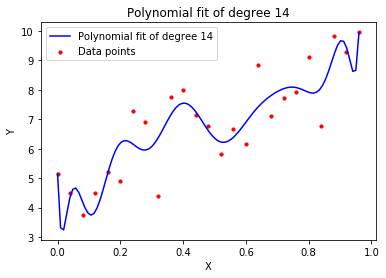

In [48]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 14) fit

In [49]:
# Mean Squared Error (MSE)
msefourteen = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msefourteen:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredfourteen = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredfourteen:.4f}')

Mean Squared Error: 0.6442
R-squared: 0.7879


using polynomial fit of degree 15

In [50]:
# Polynomial fitting using NumPy's polyfit
degree = 15 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [ 1.34226120e+09 -9.57381174e+09  3.07728145e+10 -5.89035903e+10
  7.47528470e+10 -6.62674236e+10  4.21194658e+10 -1.93922625e+10
  6.45729243e+09 -1.53579788e+09  2.54528096e+08 -2.81972586e+07
  1.94720535e+06 -7.35088838e+04  1.09558838e+03  5.14288993e+00]


plotting

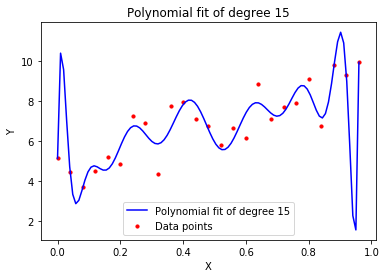

In [51]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 15) fit

In [52]:
# Mean Squared Error (MSE)
msefifteen = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msefifteen:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredfifteen = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredfifteen:.4f}')

Mean Squared Error: 0.3938
R-squared: 0.8703


using polynomial fit of degree 16

In [53]:
# Polynomial fitting using NumPy's polyfit
degree = 16 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,.96,100)
y_pred = polynomial(x)

Polynomial Coefficients:  [ 6.71532828e+08 -3.81511072e+09  8.42638602e+09 -7.01042193e+09
 -5.70639079e+09  2.17023619e+10 -2.76974038e+10  2.13894946e+10
 -1.11294989e+10  4.02930699e+09 -1.01784502e+09  1.76438733e+08
 -2.02298568e+07  1.43494218e+06 -5.52805456e+04  8.31540744e+02
  5.14363605e+00]


plotting

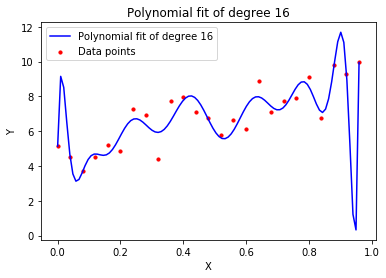

In [54]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points', s=10) # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title(f'Polynomial fit of degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (degree 16) fit

In [55]:
# Mean Squared Error (MSE)
msesixteen = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msesixteen:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredsixteen = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredsixteen:.4f}')

Mean Squared Error: 0.3915
R-squared: 0.8711


MSE decreases and R-squared increases with a higher polynomial, but the prediction is less useful because it is overfit. From the plots the function can be seen to fit the noise of the data, not the trend.

# PART C

creating vandermonde matrix

In [56]:
# Create Vandermonde matrix for a polynomial of degree 3
degree = 3
V = np.vander(X1, N=degree+1, increasing=True)

using vandermonde matrix

In [57]:
# V.T * V
VT_V = np.dot(V.T, V)

# V.T * y
VT_y = np.dot(V.T, Y1)

# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)

# Generate polynomial function based on the coefficients
x = np.linspace(0,5,50)
polynomial = np.poly1d(coefficients[::-1])  # reverse the order
y_pred = polynomial(x)

plotting

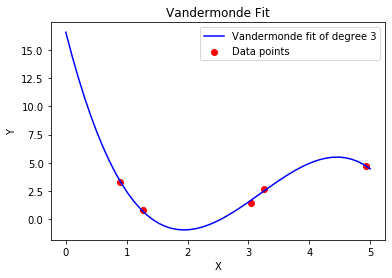

In [58]:
# Plotting the results
plt.scatter(X1, Y1, color='red', label='Data points') # Original data points
plt.plot(x, y_pred, color='blue', label=f'Vandermonde fit of degree {degree}')
plt.title('Vandermonde Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()